# IMDB Reviews - Interpretability (SHAP / LIME)

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import numpy as np, shap
from lime.lime_text import LimeTextExplainer

def shap_explain_tfidf(pipeline, texts, nsamples=100):
    clf = pipeline.named_steps['clf']; vec = pipeline.named_steps['tfidf']
    def predict(raw):
        X = vec.transform(raw)
        if hasattr(clf, 'predict_proba'):
            return clf.predict_proba(X)
        from scipy.special import expit
        s = clf.decision_function(X)
        if s.ndim == 1:
            p1 = expit(s); return np.vstack([1-p1, p1]).T
        return s
    background = vec.transform(texts[:20])
    explainer = shap.KernelExplainer(predict, background)
    shap_values = explainer.shap_values(texts[:5], nsamples=nsamples)
    return shap_values

def shap_explain_tfidf_linear(pipeline, texts,
                              background_size=400, sample_size=20):
    clf = pipeline.named_steps['clf']
    vec = pipeline.named_steps['tfidf']
    X_bg = vec.transform(texts[:background_size])
    X_eval = vec.transform(texts[:sample_size])

    explainer = shap.LinearExplainer(clf, X_bg, feature_perturbation="interventional")
    shap_values = explainer.shap_values(X_eval)
    return shap_values, X_eval

def lime_explain_text(pipeline, text):
    clf = pipeline.named_steps['clf']; vec = pipeline.named_steps['tfidf']
    def predict_proba(raw):
        X = vec.transform(raw)
        if hasattr(clf, 'predict_proba'):
            return clf.predict_proba(X)
        from scipy.special import expit
        s = clf.decision_function(X)
        if s.ndim == 1:
            p1 = expit(s); return np.vstack([1-p1, p1]).T
        return s
    explainer = LimeTextExplainer(class_names=['neg','pos'])
    return explainer.explain_instance(text, predict_proba, num_features=10)

In [7]:
import joblib, pandas as pd
from pathlib import Path

# Load model and data
pipe = joblib.load('../models/svm_tfidf_model.joblib')
data_path = Path('../data/sample_imdb_tiny.csv')
df = pd.read_csv(data_path)

# Compute SHAP and LIME explanations
texts = df['text'].tolist()[:100]
shap_vals, X_eval = shap_explain_tfidf_linear(pipe, texts, sample_size=50)
print('Computed SHAP values.')
example_text = texts[0]
exp = lime_explain_text(pipe, example_text)
print('LIME explanation:')
for word, weight in exp.as_list():
    print(f'{word}: {weight:.3f}')

Computed SHAP values.
LIME explanation:
loved: 0.216
outstanding: 0.101
absolutely: -0.054
story: -0.024
performances: 0.022
movie: 0.015
moved: 0.009
I: 0.002
the: 0.002
and: -0.001


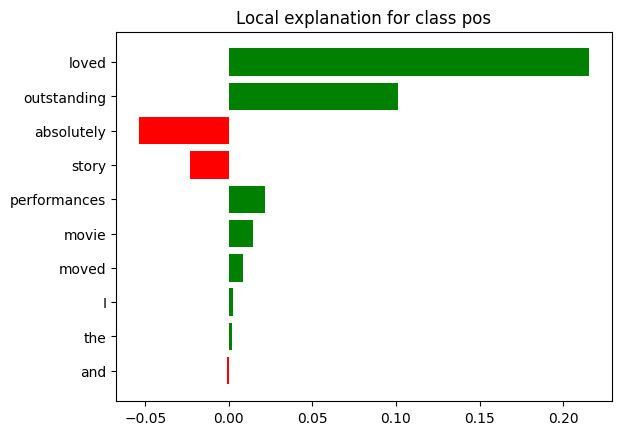

In [8]:
# Plot lime explanation
import matplotlib.pyplot as plt
fig = exp.as_pyplot_figure()
plt.show()

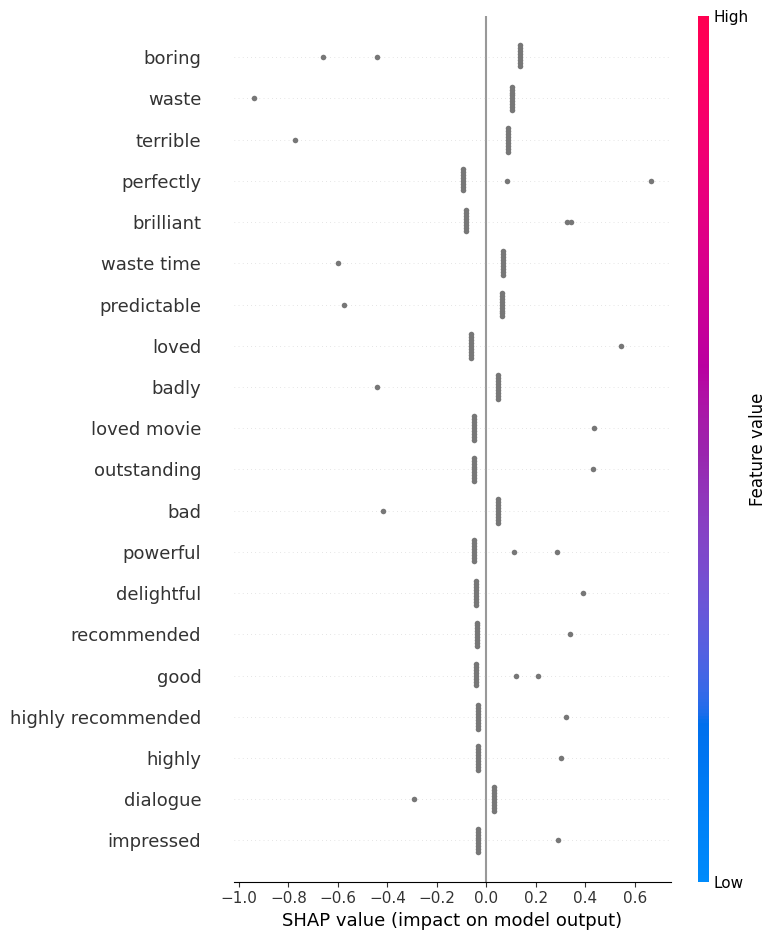

In [9]:
shap.summary_plot(shap_vals, X_eval, feature_names=pipe.named_steps['tfidf'].get_feature_names_out())